https://www.kaggle.com/datasets/milanzdravkovic/pharma-sales-data

The dataset is built from the initial dataset consisted of 600000 transactional data collected in 6 years (period 2014-2019), indicating date and time of sale, pharmaceutical drug brand name and sold quantity, exported from Point-of-Sale system in the individual pharmacy. Selected group of drugs from the dataset (57 drugs) is classified to the following Anatomical Therapeutic Chemical (ATC) Classification System categories:

M01AB - Anti-inflammatory and antirheumatic products, non-steroids, Acetic acid derivatives and related substances \
M01AE - Anti-inflammatory and antirheumatic products, non-steroids, Propionic acid derivatives \
N02BA - Other analgesics and antipyretics, Salicylic acid and derivatives \
N02BE/B - Other analgesics and antipyretics, Pyrazolones and Anilides \
N05B - Psycholeptics drugs, Anxiolytic drugs \
N05C - Psycholeptics drugs, Hypnotics and sedatives drugs \
R03 - Drugs for obstructive airway diseases \
R06 - Antihistamines for systemic use

Sales data are resampled to the hourly, daily, weekly and monthly periods. Data is already pre-processed, where processing included outlier detection and treatment and missing data imputation.

The creator of the dataset didn't mention magnitude of the units of the sold products, so i'll conclude that it's in millions of products.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so

In [2]:
sales_monthly = pd.read_csv('pharma_sales_Data\salesmonthly.csv')

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
C:\Users\DELL\AppData\Local\Temp\ipykernel_14992\1297854031.py:1: SyntaxWarning: invalid escape sequence '\s'
  sales_monthly = pd.read_csv('pharma_sales_Data\salesmonthly.csv')


**Exploratory and Data Analysis (EDA)**

In [3]:
sales_monthly.sample(10)

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
0,2014-01-31,127.69,99.090,152.100,878.030,354.0,50.0,112.0,48.20
26,2016-03-31,156.64,180.589,148.400,1150.700,250.0,13.0,253.0,97.84
19,2015-08-31,181.69,144.519,133.400,790.788,265.5,15.0,45.0,83.70
3,2014-04-30,113.10,89.475,130.900,698.500,209.0,18.0,97.0,73.70
11,2014-12-31,131.90,121.401,111.124,1015.660,492.0,25.0,163.0,33.40
62,2019-03-31,154.52,113.118,83.350,941.050,301.4,19.0,257.0,169.50
5,2014-06-30,112.07,94.710,122.900,548.225,323.0,23.0,57.0,109.30
44,2017-09-30,138.33,118.711,88.150,863.750,223.0,23.0,139.0,66.90
10,2014-11-30,138.08,100.860,142.700,723.800,489.0,19.0,112.0,45.20
38,2017-03-31,162.85,111.055,107.350,612.500,165.0,9.0,139.0,100.10


In [4]:
sales_monthly.info()

<class 'pandas.DataFrame'>
RangeIndex: 70 entries, 0 to 69
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   datum   70 non-null     str    
 1   M01AB   70 non-null     float64
 2   M01AE   70 non-null     float64
 3   N02BA   70 non-null     float64
 4   N02BE   70 non-null     float64
 5   N05B    70 non-null     float64
 6   N05C    70 non-null     float64
 7   R03     70 non-null     float64
 8   R06     70 non-null     float64
dtypes: float64(8), str(1)
memory usage: 5.1 KB


A quick view

<Axes: >

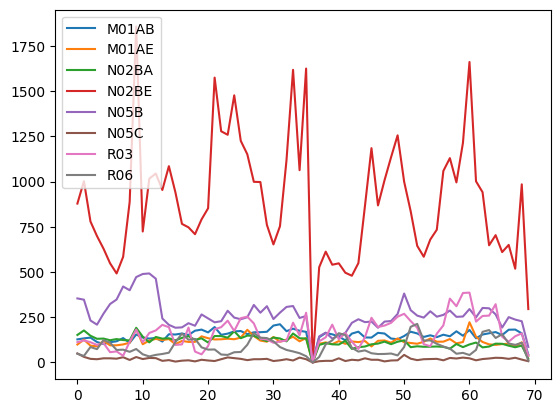

In [5]:
sales_monthly.plot()

Checking the shape of distributions

array([[<Axes: title={'center': 'M01AB'}>,
        <Axes: title={'center': 'M01AE'}>,
        <Axes: title={'center': 'N02BA'}>],
       [<Axes: title={'center': 'N02BE'}>,
        <Axes: title={'center': 'N05B'}>,
        <Axes: title={'center': 'N05C'}>],
       [<Axes: title={'center': 'R03'}>, <Axes: title={'center': 'R06'}>,
        <Axes: >]], dtype=object)

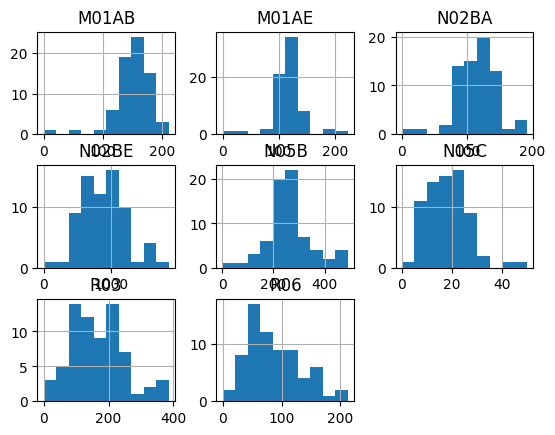

In [6]:
sales_monthly.hist()

What about outliers?

Text(0.5, 1.0, 'Boxplot for Monthly Sales')

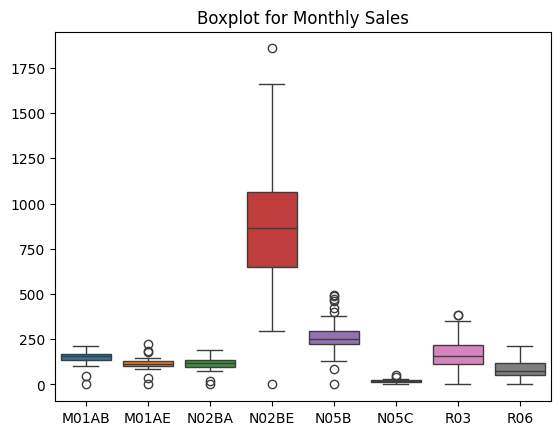

In [7]:
sns.boxplot(sales_monthly)
plt.title('Boxplot for Monthly Sales')

There are outliers. Outliers close to zero correspond to the time series drop. \
In this case: *N02BE/B - Other analgesics and antipyretics, Pyrazolones and Anilides*

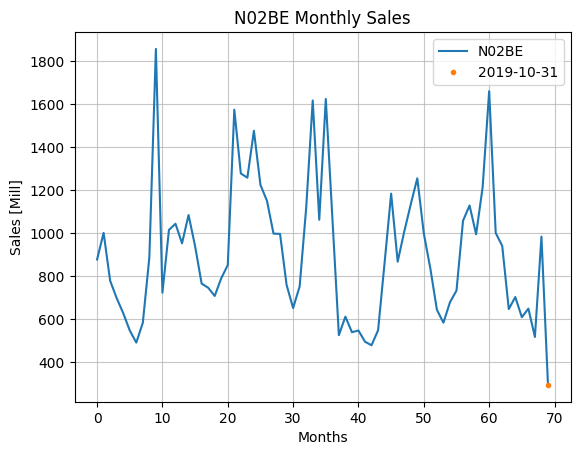

In [16]:
sales_monthly.N02BE.plot()
plt.plot(sales_monthly.N02BE.argmin(),sales_monthly.N02BE.min(),'.',label=sales_monthly.loc[sales_monthly.N02BE.argmin()].datum)
plt.legend()
plt.title('N02BE Monthly Sales')
plt.xlabel('Months')
plt.ylabel('Sales [Mill]')
plt.grid('.',alpha=.7,)

Googling that date I found nothing happened on 2017-01-31, so it should be an error. I'm filling that record with interpolation. I've noticed that this happens on the other Series, so I'm correcting those as well (this is responsible for the low end outliers of the boxplot)

In [9]:
sales_monthly['N02BE'] = sales_monthly['N02BE'].replace(0, np.nan).interpolate()

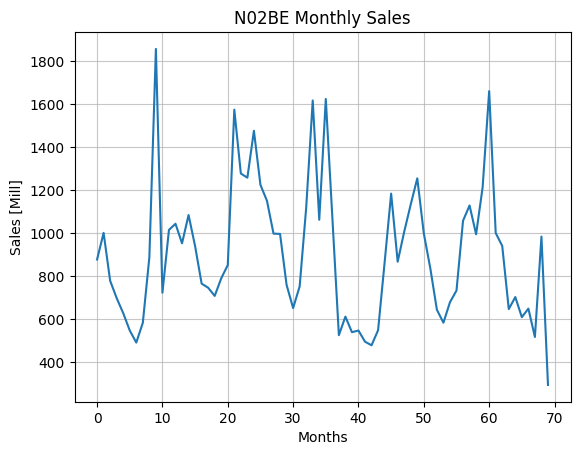

In [15]:
sales_monthly.N02BE.plot()
plt.title('N02BE Monthly Sales')
plt.xlabel('Months')
plt.ylabel('Sales [Mill]')
plt.grid('.',alpha=.7,)

In [11]:
for col in sales_monthly.select_dtypes(include='number').columns:
    sales_monthly[col] = sales_monthly[col].replace(0, np.nan).interpolate()

Text(0.5, 1.0, 'Boxplot for Monthly Sales')

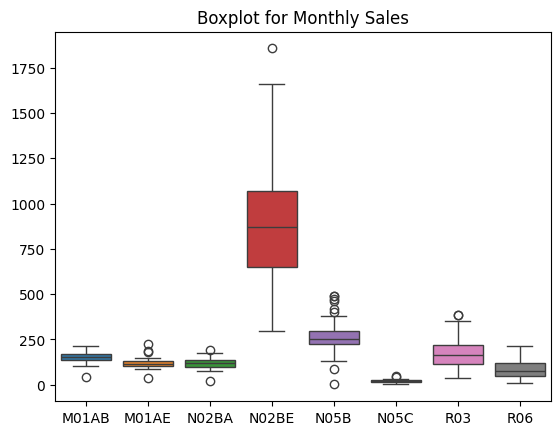

In [12]:
sns.boxplot(sales_monthly)
plt.title('Boxplot for Monthly Sales')

Fixed for some of them!